In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from numpy import genfromtxt

# Intro

In [ ]:
import torch
# First method

# model = nn.Sequential(
#     nn.Linear(in_features=10, out_features=1)
# )

# 2 inputs, 2 hidden layer, 1 output
# model = nn.Sequential(
#     nn.Linear(in_features=2, out_features=5),   # 2 input
#     nn.ReLU(),
#     nn.Linear(in_features=5, out_features=2),   # 1st hidden layer
#     nn.ReLU(),
#     nn.Linear(in_features=2, out_features=1),   # 2nd hidden layer and an output
#     nn.Tanh()
# )

# Task A

## Testing code

In [ ]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

inputs = np.random.rand(3, 2)
targets = np.random.rand(3, 1)

inputs_tch = torch.FloatTensor(inputs)
targets_tch = torch.FloatTensor(targets)

print(inputs_tch)
print(targets_tch)

torch_dataset = TensorDataset(inputs_tch, targets_tch)
print(f'Content of torch_dataset: {vars(torch_dataset)}')

tuple_of_tensors = torch_dataset.tensors
print(f'Content of tuple_of_tensors: {tuple_of_tensors}')
list_of_tensors = list(tuple_of_tensors)
print(f'Content of list_of_tensors: {list_of_tensors}')

train_loader = DataLoader(torch_dataset, batch_size=2, shuffle=True)
print(' train loader ')
for x, t in train_loader:
    print(x)
    print(t)

tensor([[0.5711, 0.3920],
        [0.5932, 0.2723],
        [0.2933, 0.5136]])
tensor([[0.1958],
        [0.0195],
        [0.1077]])
Content of torch_dataset: {'tensors': (tensor([[0.5711, 0.3920],
        [0.5932, 0.2723],
        [0.2933, 0.5136]]), tensor([[0.1958],
        [0.0195],
        [0.1077]]))}
Content of tuple_of_tensors: (tensor([[0.5711, 0.3920],
        [0.5932, 0.2723],
        [0.2933, 0.5136]]), tensor([[0.1958],
        [0.0195],
        [0.1077]]))
Content of list_of_tensors: [tensor([[0.5711, 0.3920],
        [0.5932, 0.2723],
        [0.2933, 0.5136]]), tensor([[0.1958],
        [0.0195],
        [0.1077]])]
 train loader 
tensor([[0.2933, 0.5136],
        [0.5711, 0.3920]])
tensor([[0.1077],
        [0.1958]])
tensor([[0.5932, 0.2723]])
tensor([[0.0195]])


## Problem 2

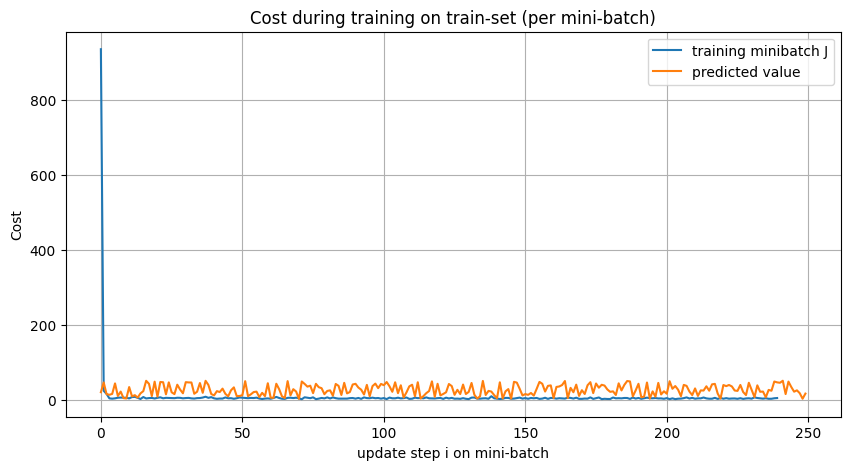

('0.weight', Parameter containing:
tensor([[4.9131]], requires_grad=True))
('0.bias', Parameter containing:
tensor([2.4830], requires_grad=True))


In [ ]:
# Problem 2.1
a_true = 5.0
b_true = 3.0
sigma_epsilon = 2.0

X = np.random.uniform(0, 10, 250)
y_obs = a_true*X + b_true + sigma_epsilon*np.random.randn(len(X))

X = torch.tensor(X).reshape(len(X),1).float()
y_obs = torch.tensor(y_obs).reshape(len(y_obs),1).float()


# Problem 2.2
torch_Dataset = TensorDataset(X, y_obs)
train_loader = DataLoader(torch_Dataset, batch_size=16, shuffle=True)

# Problem 2.3
model = nn.Sequential(
    nn.Linear(in_features=1, out_features=1)
)

# Problem 2.4
cost_function = nn.MSELoss()  # I chose MSELoss becuase of my low noise level in sigma_epsilon

# Problem 2.5
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Problem 2.6
training_minibatch_Js = []
nr_epochs = 15
for epoch_i in range(nr_epochs):
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        cost = cost_function(y_pred, y_batch)
        optimizer.zero_grad()
        cost.backward()
        optimizer.step()
        training_minibatch_Js.append(cost.item())

plt.figure(figsize=[10, 5])
plt.plot(training_minibatch_Js, label='training minibatch J')
plt.xlabel('update step i on mini-batch')
plt.ylabel('Cost')
plt.title('Cost during training on train-set (per mini-batch)')
plt.grid()

# Problem 2.7
with torch.no_grad():
    y_preds = model(X)

plt.plot(y_preds, label="predicted value")
plt.legend()
plt.show()

# Problem 2.8
for p in model.named_parameters():
    print(p)

# Problem 3

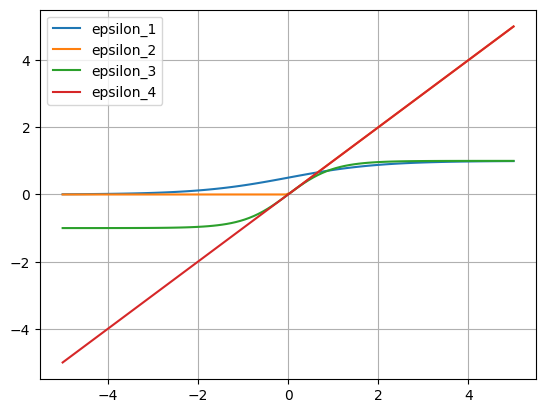

In [ ]:
# Problem 3.1
# (a)
def epsilon_1(v):
  return 1/(1+np.exp(-v))

def epsilon_2(v):
  return np.maximum(0, v)

def epsilon_3(v):
  return np.tanh(v)

def epsilon_4(v):
  return v

x = np.linspace(-5, 5, 100)
y_1 = epsilon_1(x)
y_2 = epsilon_2(x)
y_3 = epsilon_3(x)
y_4 = epsilon_4(x)

plt.plot(x, y_1, label='epsilon_1')
plt.plot(x, y_2, label='epsilon_2')
plt.plot(x, y_3, label='epsilon_3')
plt.plot(x, y_4, label='epsilon_4')
plt.legend()
plt.grid()


## Problem 3.2

FANN layout: 2-5-2-1

1st layer: 2*5+5 = 15

2nd layer: 5*2+2 = 12

3rd layer: 2*1+1 = 3

total changable parameters = 30

# Task B

Converged at epoch 2, cost: 0.02879


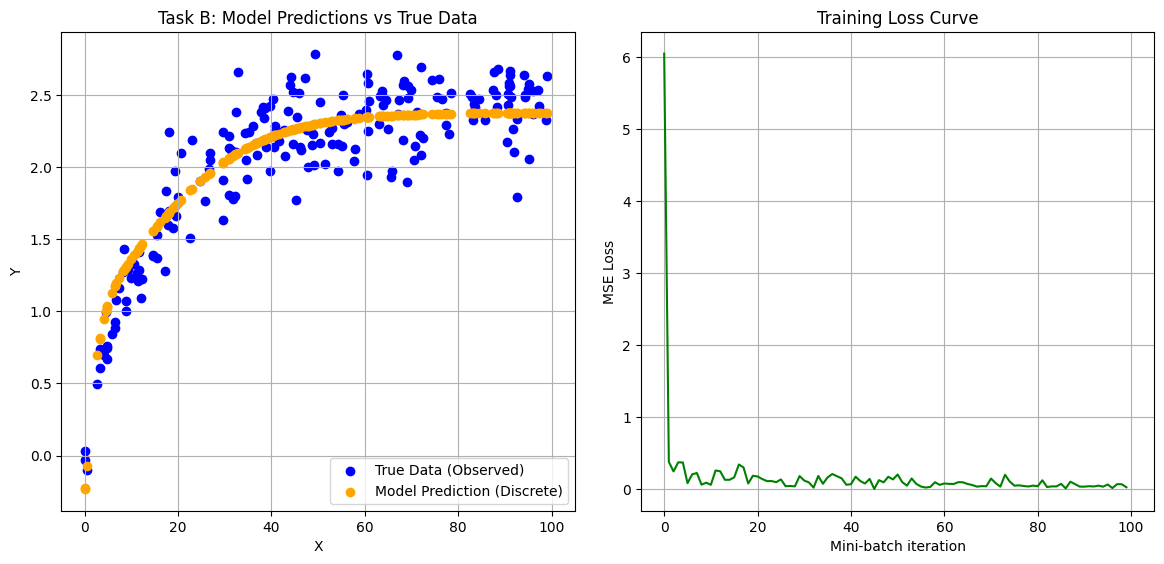

In [71]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from numpy import genfromtxt

# Load the Marvin Minsky dataset
my_data = genfromtxt('dataset_Marvin_Minsky.csv', delimiter=',', skip_header=1)
X = my_data[:, 0]  # Extract X values
y_obs = my_data[:, 1]  # Extract y values

# Convert to PyTorch tensors
X = torch.tensor(X).reshape(-1, 1).float()  # Reshape to column vector
y_obs = torch.tensor(y_obs).reshape(-1, 1).float()

# Create PyTorch Dataset and DataLoader
my_dataset = TensorDataset(X, y_obs)
my_dataloader = DataLoader(my_dataset, batch_size=4, shuffle=True)

model = nn.Sequential(
    nn.Linear(1, 75),
    nn.Tanh(),
    nn.Linear(75, 75),
    nn.Tanh(),
    nn.Linear(75, 1)
)

# Define the loss function and optimizer
cost_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Train the model
training_minibatch_Js = []  # Store training costs
nr_epochs = 100  # Long enough to converge
for epoch in range(nr_epochs):
    for X_batch, y_batch in my_dataloader:
        # Forward pass
        y_pred = model(X_batch)
        cost = cost_function(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        training_minibatch_Js.append(cost.item())

    # Stop early if MSE is sufficiently low
    if cost.item() < 0.1:
        print(f"Converged at epoch {epoch + 1}, cost: {cost.item():.5f}")
        break

# Generate predictions for the original input values (discrete)
with torch.no_grad():
    y_preds = model(X)

# Create a figure with a wider aspect ratio
plt.figure(figsize=(12, 6))  # Adjust figure size for more space

# Subplot 1: Scatter plot of true data and predictions
plt.subplot(1, 2, 1)  # Create the first subplot (1 row, 2 columns, position 1)
plt.scatter(X.numpy(), y_obs.numpy(), color="blue", label="True Data (Observed)")
plt.scatter(X.numpy(), y_preds.numpy(), color="orange", label="Model Prediction (Discrete)", marker='o')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Task B: Model Predictions vs True Data")
plt.grid()
plt.legend()
plt.xlim(-5, 105)  # Extend x-axis range

# Subplot 2: Cost over epochs
plt.subplot(1, 2, 2)  # Create the second subplot (1 row, 2 columns, position 2)
plt.plot(training_minibatch_Js, color="green")
plt.xlabel("Mini-batch iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.xlim(-5, 105)  # Extend x-axis range if applicable

# Adjust layout to add some padding
plt.tight_layout(pad=2.0)  # Add padding between subplots

# Show the figure
plt.show()


# Task C

<ipython-input-2-0ff74917e890>:8: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  y[i] = torch.exp(-((x[i,:]-mean_true).T@(x[i,:]-mean_true))/16)+sigma_noise*torch.randn(1)


Architecture I (2-40-1): Final cost = 0.0034
Architecture II (2-40-40-40-1): Final cost = 0.0005


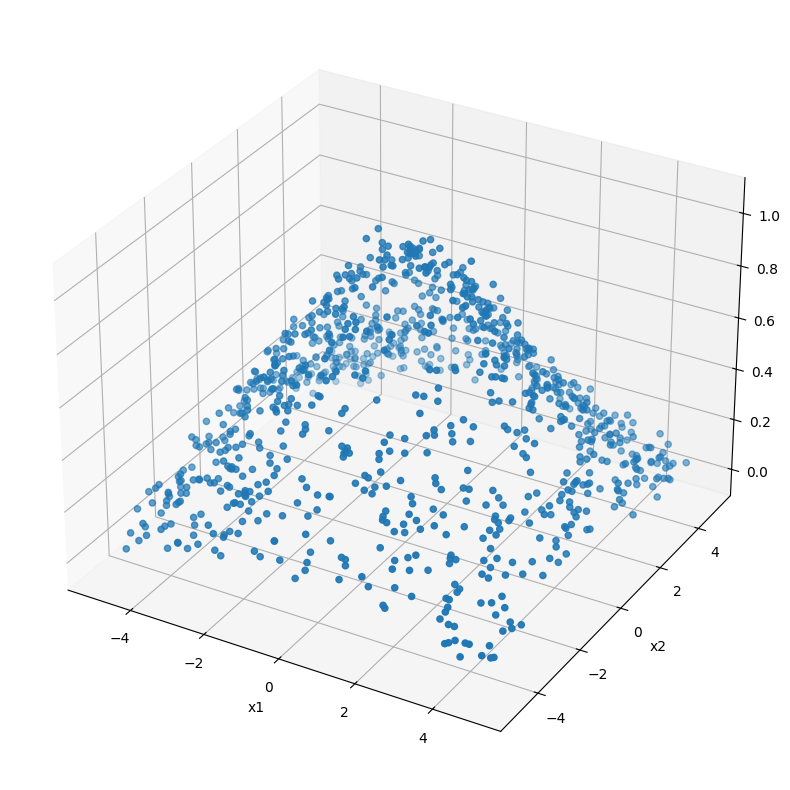

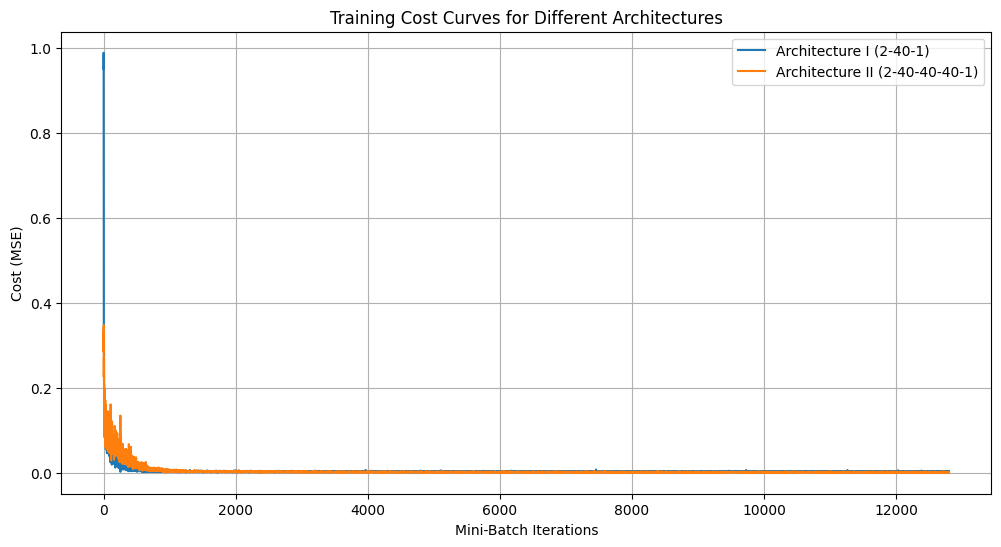


Final Costs for Architectures:
Architecture I (2-40-1): 0.0034
Architecture II (2-40-40-40-1): 0.0005


In [ ]:
# (a)
N = 1000 # Nr of data - points to sample and generate
x = 10*torch.rand(size = [N, 2])-5
mean_true = torch.tensor([0.0, 0.0])
sigma_noise = 0.04
y = torch.zeros(N).reshape(-1, 1)
for i in range (len(x)):
    y[i] = torch.exp(-((x[i,:]-mean_true).T@(x[i,:]-mean_true))/16)+sigma_noise*torch.randn(1)

 # Plotting
fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(10)
ax = plt.axes(projection = '3d')
ax.scatter(x[:,0],x[:,1],y)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

my_dataset = TensorDataset(x,y) # do
dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)


# (b)
architectures = {
    "Architecture I (2-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.ReLU(),
        nn.Linear(40, 1)
    ),
    "Architecture II (2-40-40-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 1)
    )
}


# (c)
learning_rate = 0.01
nr_epochs = 400
final_costs = {}  # Store final costs for each architecture
training_curves = {}  # Store cost curves

# Train each architecture
for name, model in architectures.items():
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    cost_function = nn.MSELoss()
    training_minibatch_Js = []  # Store costs for the current architecture

    for epoch in range(nr_epochs):
        for x_batch, y_batch in dataloader:
            # Forward pass
            y_pred = model(x_batch)
            cost = cost_function(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            training_minibatch_Js.append(cost.item())

    # Store the final cost and training curve
    final_costs[name] = cost.item()
    training_curves[name] = training_minibatch_Js

    print(f"{name}: Final cost = {cost.item():.4f}")

# Plot training cost curves
plt.figure(figsize=(12, 6))
for name, curve in training_curves.items():
    plt.plot(curve, label=name)

plt.xlabel("Mini-Batch Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Training Cost Curves for Different Architectures")
plt.legend()
plt.grid()
plt.show()

# Print final costs
print("\nFinal Costs for Architectures:")
for name, cost in final_costs.items():
    print(f"{name}: {cost:.4f}")



 abs max =  0.09561482


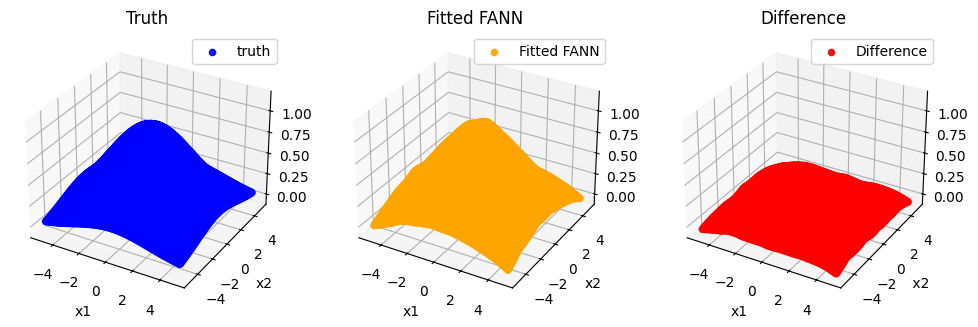

In [ ]:
x1 = torch.linspace(start = -5, end =5, steps =100)
x2 = torch.linspace(start = -5, end =5, steps =100)
X , Y = torch . meshgrid ( x1 , x2 )

s = torch.stack([X.ravel(), Y.ravel()]).T # all grid coordinates

y_true = torch.zeros(len(s)).reshape(-1 ,1)
y_preds = torch.zeros(len(s)).reshape(-1 ,1)
for i in range(len(s)):
  y_true[i] = torch.exp(-((s[i ,:] - mean_true) @ ((s[i ,:] - mean_true).T))/16) + 0.0 * torch.randn(1)
  with torch.no_grad():
    y_preds[i] = model(s[i ,:])

 # 3 D Surface plotting
fig,(ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection' : '3d'}, figsize=(12, 5))


ax1.scatter(s[:, 0], s[:, 1], y_true, c='blue', label='truth', alpha =0.9)
ax1.set_title('Truth')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.legend()
ax1.set_zlim(-0.1, 1.2) # Set z - axis limits

ax2.scatter(s[:, 0], s[:, 1], y_preds, c='orange', label='Fitted FANN', alpha =0.9)
ax2.set_title('Fitted FANN')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.legend()
ax2.set_zlim(-0.1, 1.2) # Set z - axis limits

d = y_preds - y_true
print("abs max = ", np.max(np.abs(d.numpy())))
ax3.scatter(s[:, 0], s[:, 1], d, c='red', label='Difference', alpha =0.9)
ax3.set_title('Difference')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.legend()
ax3.set_zlim(-0.1, 1.2) ; # Set z - axis limits

# Task D

In [ ]:
N = 500
x = 10*torch.rand(size = [N, 2])-5
mean_true = torch.tensor([0.0, 0.0])

architectures = {
    "Architecture I (2-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.ReLU(),
        nn.Linear(40, 1)
    ),
    "Architecture II (2-40-40-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 1)
    )
}

learning_rate = 0.01
nr_epochs = 400

cost_list = []
sigma_noise_true = 0
sigma_noise = [0.1, 0.3, 0.5, 0.7, 0.8]

for sigma in sigma_noise:
    print(sigma)
    y = torch.zeros(N).reshape(-1, 1)
    for i in range (len(x)):
        y[i] = torch.exp(-((x[i,:]-mean_true).T@(x[i,:]-mean_true))/16)+sigma*torch.randn(1)

    my_dataset = TensorDataset(x,y) # do
    dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)
    final_costs = {}  # Store final costs for each architecture
    training_curves = {}  # Store cost curves

    # Train each architecture
    for name, model in architectures.items():
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
        cost_function = nn.MSELoss()
        training_minibatch_Js = []  # Store costs for the current architecture

        for epoch in range(nr_epochs):
            for x_batch, y_batch in dataloader:
                # Forward pass
                y_pred = model(x_batch)
                cost = cost_function(y_pred, y_batch)

                # Backward pass
                optimizer.zero_grad()
                cost.backward()
                optimizer.step()

                training_minibatch_Js.append(cost.item())


        # Store the final cost and training curve
        final_costs[name] = cost.item()
        training_curves[name] = training_minibatch_Js
        cost_list.append(cost.item())

        print(f"{name}: Final cost = {cost.item():.4f}")

arc1 = np.sqrt(sum([i*i for i in cost_list if cost_list.index(i) % 2 == 0])/(len(cost_list)/2))
arc2 = np.sqrt(sum([i*i for i in cost_list if cost_list.index(i) % 2 != 0])/(len(cost_list)/2))

print(arc1)
print(arc2)

# arc2 better


0.1
Architecture I (2-40-1): Final cost = 0.0122
Architecture II (2-40-40-40-1): Final cost = 0.0112
0.3
Architecture I (2-40-1): Final cost = 0.0723
Architecture II (2-40-40-40-1): Final cost = 0.0973
0.5
Architecture I (2-40-1): Final cost = 0.3683
Architecture II (2-40-40-40-1): Final cost = 0.1484
0.7
Architecture I (2-40-1): Final cost = 0.6104
Architecture II (2-40-40-40-1): Final cost = 0.3364
0.8
Architecture I (2-40-1): Final cost = 0.9403
Architecture II (2-40-40-40-1): Final cost = 0.5888
0.5287134511915513
0.3135246218535787


Architecture II (2-40-40-40-1): Final cost = 0.0023


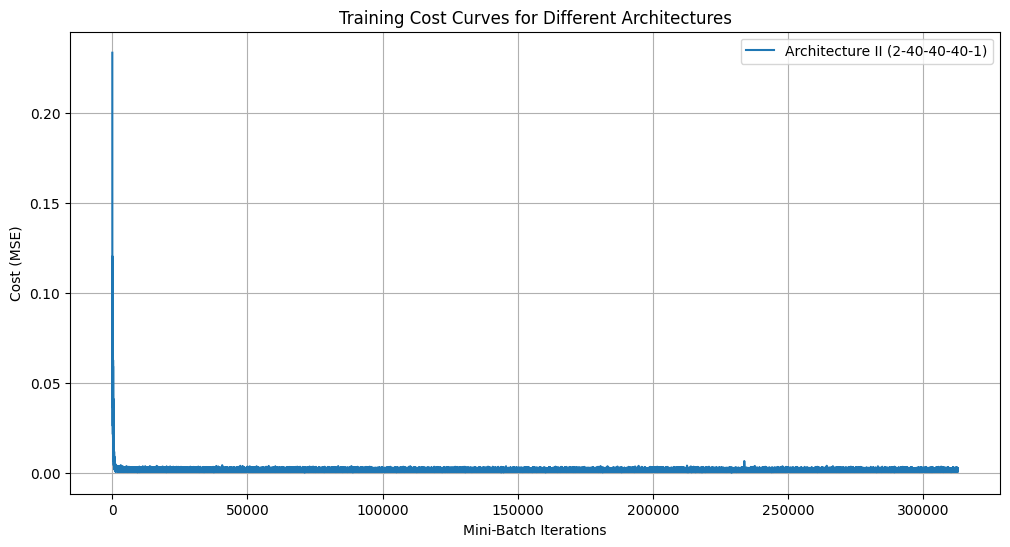


Final Costs for Architectures:
Architecture II (2-40-40-40-1): 0.0023


In [ ]:

N = 25000 # Nr of data - points to sample and generate
x = 10*torch.rand(size = [N, 2])-5
mean_true = torch.tensor([0.0, 0.0])
sigma_noise = 0.04
y = torch.zeros(N).reshape(-1, 1)
for i in range (len(x)):
    y[i] = torch.exp(-((x[i,:]-mean_true).T@(x[i,:]-mean_true))/16)+sigma_noise*torch.randn(1)

 # Plotting
''' fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(10)
ax = plt.axes(projection = '3d')
ax.scatter(x[:,0],x[:,1],y)
ax.set_xlabel('x1')
ax.set_ylabel('x2') '''

my_dataset = TensorDataset(x,y) # do
dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)



architectures = {
    "Architecture II (2-40-40-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 40),
        nn.ReLU(),
        nn.Linear(40, 1)
    )
}


learning_rate = 0.01
nr_epochs = 400
final_costs = {}  # Store final costs for each architecture
training_curves = {}  # Store cost curves

# Train each architecture
for name, model in architectures.items():
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    cost_function = nn.MSELoss()
    training_minibatch_Js = []  # Store costs for the current architecture

    for epoch in range(nr_epochs):
        for x_batch, y_batch in dataloader:
            # Forward pass
            y_pred = model(x_batch)
            cost = cost_function(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            training_minibatch_Js.append(cost.item())

    # Store the final cost and training curve
    final_costs[name] = cost.item()
    training_curves[name] = training_minibatch_Js

    print(f"{name}: Final cost = {cost.item():.4f}")

# Plot training cost curves
plt.figure(figsize=(12, 6))
for name, curve in training_curves.items():
    plt.plot(curve, label=name)

plt.xlabel("Mini-Batch Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Training Cost Curves for Different Architectures")
plt.legend()
plt.grid()
plt.show()

# Print final costs
print("\nFinal Costs for Architectures:")
for name, cost in final_costs.items():
    print(f"{name}: {cost:.4f}")

Architecture I (2-40-1): Final cost = 0.0270


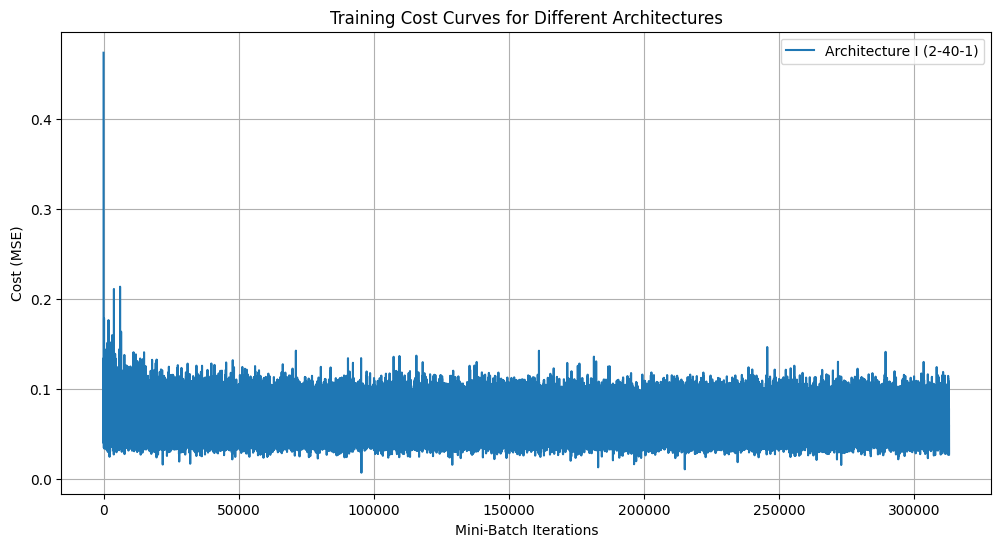


Final Costs for Architectures:
Architecture I (2-40-1): 0.0270


In [5]:
N = 25000 # Nr of data - points to sample and generate
x = 10*torch.rand(size = [N, 2])-5
mean_true = torch.tensor([0.0, 0.0])
sigma_noise = 0.04
y = torch.zeros(N).reshape(-1, 1)
for i in range (len(x)):
    y[i] = torch.exp(-((x[i,:]-mean_true).T@(x[i,:]-mean_true))/16)+sigma_noise*torch.randn(1)

 # Plotting
''' fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(10)
ax = plt.axes(projection = '3d')
ax.scatter(x[:,0],x[:,1],y)
ax.set_xlabel('x1')
ax.set_ylabel('x2') '''

my_dataset = TensorDataset(x,y) # do
dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)



architectures = {
    "Architecture I (2-40-1)": nn.Sequential(
        nn.Linear(2, 40),
        nn.Linear(40, 1)
    )
}


learning_rate = 0.01
nr_epochs = 400
final_costs = {}  # Store final costs for each architecture
training_curves = {}  # Store cost curves

# Train each architecture
for name, model in architectures.items():
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    cost_function = nn.MSELoss()
    training_minibatch_Js = []  # Store costs for the current architecture

    for epoch in range(nr_epochs):
        for x_batch, y_batch in dataloader:
            # Forward pass
            y_pred = model(x_batch)
            cost = cost_function(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            training_minibatch_Js.append(cost.item())

    # Store the final cost and training curve
    final_costs[name] = cost.item()
    training_curves[name] = training_minibatch_Js

    print(f"{name}: Final cost = {cost.item():.4f}")

# Plot training cost curves
plt.figure(figsize=(12, 6))
for name, curve in training_curves.items():
    plt.plot(curve, label=name)

plt.xlabel("Mini-Batch Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Training Cost Curves for Different Architectures")
plt.legend()
plt.grid()
plt.show()

# Print final costs
print("\nFinal Costs for Architectures:")
for name, cost in final_costs.items():
    print(f"{name}: {cost:.4f}")